# 集成学习

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
import matplotlib as mpl

## 投票分类器

In [3]:
heads_proba = 0.51
coin_tosses = (np.random.rand(10000, 10) < heads_proba).astype(np.int32)
cumulative_heads_ratio = np.cumsum(coin_tosses, axis=0) / np.arange(
    1, 10001).reshape(-1, 1)

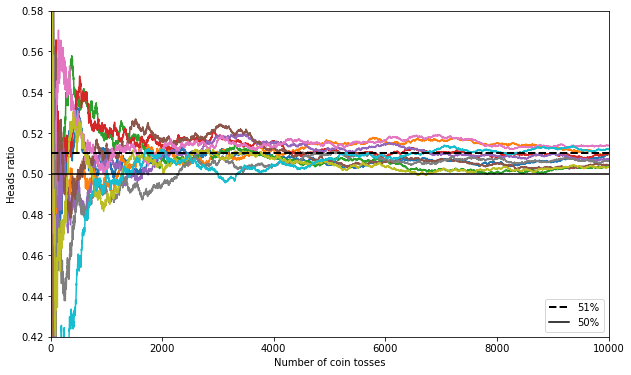

In [4]:
_, ax = plt.subplots(figsize=(10, 6))

ax.plot(cumulative_heads_ratio)
ax.plot([0, 10000], [0.51, 0.51], "k--", lw=2, label="51%")
ax.plot([0, 10000], [0.5, 0.5], "k-", label="50%")
ax.set(xlabel="Number of coin tosses",
       ylabel="Heads ratio",
       xlim=[0, 10000],
       ylim=[0.42, 0.58])
ax.legend(loc="lower right")

plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

In [6]:
X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [7]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [8]:
log_clf = LogisticRegression(solver="lbfgs", random_state=42)
rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42)
svm_clf = SVC(gamma="scale", random_state=42)

voting_clf = VotingClassifier(estimators=[('lr', log_clf), ('rf', rnd_clf),
                                          ('svc', svm_clf)],
                              voting='hard')

In [9]:
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(random_state=42)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('svc', SVC(random_state=42))])

In [10]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

In [11]:
for clf in (log_clf, rnd_clf, svm_clf, voting_clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__, accuracy_score(y_test, y_pred))

LogisticRegression 0.864
RandomForestClassifier 0.896
SVC 0.896
VotingClassifier 0.912


### 软投票

In [12]:
log_clf = LogisticRegression(solver="lbfgs", random_state=42)
rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42)
svm_clf = SVC(gamma="scale", probability=True, random_state=42)

voting_clf = VotingClassifier(estimators=[('lr', log_clf), ('rf', rnd_clf),
                                          ('svc', svm_clf)],
                              voting='soft')
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(random_state=42)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('svc', SVC(probability=True, random_state=42))],
                 voting='soft')

In [13]:
for clf in (log_clf, rnd_clf, svm_clf, voting_clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__, accuracy_score(y_test, y_pred))

LogisticRegression 0.864
RandomForestClassifier 0.896
SVC 0.896
VotingClassifier 0.92


## 袋装

In [14]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

In [15]:
bag_clf = BaggingClassifier(DecisionTreeClassifier(max_features="sqrt",
                                                   max_leaf_nodes=16),
                            n_estimators=500,
                            bootstrap=True,
                            random_state=42)
bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)

In [16]:
print(accuracy_score(y_test, y_pred))

0.912


In [17]:
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)
print(accuracy_score(y_test, y_pred_tree))

0.856


In [18]:
from mlxtend.plotting import plot_decision_regions

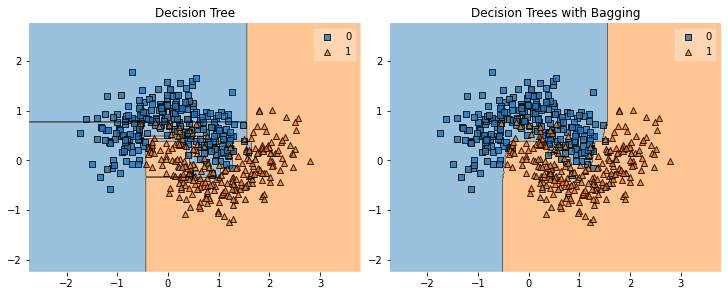

In [19]:
_, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

plot_decision_regions(X, y, clf=tree_clf, ax=axes[0])
axes[0].set(title="Decision Tree")
plot_decision_regions(X, y, clf=bag_clf, ax=axes[1])
axes[1].set(title="Decision Trees with Bagging", ylabel="")

plt.show()

### 随机森林

In [20]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(max_features="sqrt", max_leaf_nodes=16),
    n_estimators=500, random_state=42)

In [21]:
bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)

In [22]:
from sklearn.ensemble import RandomForestClassifier

In [23]:
rnd_clf = RandomForestClassifier(n_estimators=500,
                                 max_leaf_nodes=16,
                                 random_state=42)
rnd_clf.fit(X_train, y_train)

y_pred_rf = rnd_clf.predict(X_test)

In [24]:
np.sum(y_pred == y_pred_rf) / len(y_pred)  # very similar predictions

1.0

In [25]:
from sklearn.datasets import load_iris

iris = load_iris()

In [26]:
rnd_clf = RandomForestClassifier(n_estimators=500, random_state=42)
rnd_clf.fit(iris["data"], iris["target"])
for name, score in zip(iris["feature_names"], rnd_clf.feature_importances_):
    print(name, score)

sepal length (cm) 0.11249225099876375
sepal width (cm) 0.02311928828251033
petal length (cm) 0.4410304643639577
petal width (cm) 0.4233579963547682


In [27]:
rnd_clf.feature_importances_

array([0.11249225, 0.02311929, 0.44103046, 0.423358  ])

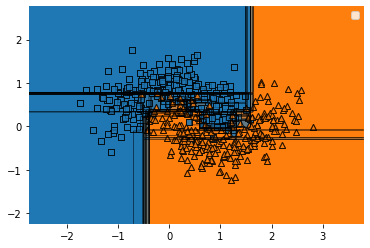

In [28]:
_, ax = plt.subplots(figsize=(6, 4))

for i in range(15):
    tree_clf = DecisionTreeClassifier(max_leaf_nodes=16, random_state=42 + i)
    indices_with_replacement = np.random.randint(0, len(X_train), len(X_train))
    tree_clf.fit(X[indices_with_replacement], y[indices_with_replacement])
    plot_decision_regions(
        X,
        y,
        clf=tree_clf,
        ax=ax,
    )
    ax.legend('')

plt.show()

### 袋外评估

In [29]:
bag_clf = BaggingClassifier(DecisionTreeClassifier(),
                            n_estimators=500,
                            bootstrap=True,
                            oob_score=True,
                            random_state=40)
bag_clf.fit(X_train, y_train)
bag_clf.oob_score_

0.8986666666666666

In [30]:
bag_clf.oob_decision_function_[:5]

array([[0.32275132, 0.67724868],
       [0.34117647, 0.65882353],
       [1.        , 0.        ],
       [0.        , 1.        ],
       [0.        , 1.        ]])

In [31]:
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.912

### 特征重要性

In [32]:
mnist_784 = np.load('../../datasets/handson/mnist_784.npz', allow_pickle=True)
X, y = mnist_784['X'], mnist_784['y']

In [33]:
rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rnd_clf.fit(X, y)

RandomForestClassifier(random_state=42)

In [34]:
def plot_digit(data, ax):
    image = data.reshape(28, 28)
    img = ax.imshow(image, cmap=mpl.cm.hot, interpolation="nearest")
    ax.axis("off")
    return img

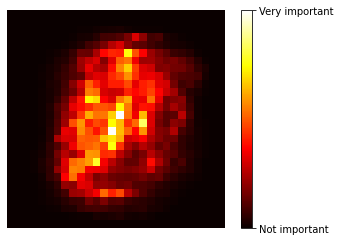

In [35]:
_, ax = plt.subplots(figsize=(6, 4))

img = plot_digit(rnd_clf.feature_importances_, ax)

cbar = _.colorbar(img,
                  ticks=[
                      rnd_clf.feature_importances_.min(),
                      rnd_clf.feature_importances_.max()
                  ],
                  ax=ax)

cbar.ax.set_yticklabels(['Not important', 'Very important'])

plt.show()

## 梯度提升

In [36]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)

In [37]:
from sklearn.tree import DecisionTreeRegressor

In [38]:
tree_reg1 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg1.fit(X, y)

y2 = y - tree_reg1.predict(X)
tree_reg2 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg2.fit(X, y2)

y3 = y2 - tree_reg2.predict(X)
tree_reg3 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg3.fit(X, y3)

DecisionTreeRegressor(max_depth=2, random_state=42)

In [39]:
X_new = np.array([[0.8]])
y_pred = sum(tree.predict(X_new) for tree in (tree_reg1, tree_reg2, tree_reg3))
y_pred

array([0.75026781])

In [40]:
def plot_predictions(regressors,
                     X,
                     y,
                     ax,
                     lims,
                     ensemble=False,
                     residual=False,
                     label=None):

    x1 = np.linspace(lims[0], lims[1], 500)
    y_pred = sum(
        regressor.predict(x1.reshape(-1, 1)) for regressor in regressors)

    style = "r-" if ensemble else "g-"
    data_style = "k+" if residual else "b."
    data_label = "Residuals" if residual else "Training Set"

    ax.plot(X[:, 0], y, data_style, label=data_label)
    ax.plot(x1, y_pred, style, lw=2, label=label)
    ax.set(xlim=[lims[0], lims[1]], ylim=[lims[2], lims[3]])
    ax.legend(loc="upper center", fontsize='large')

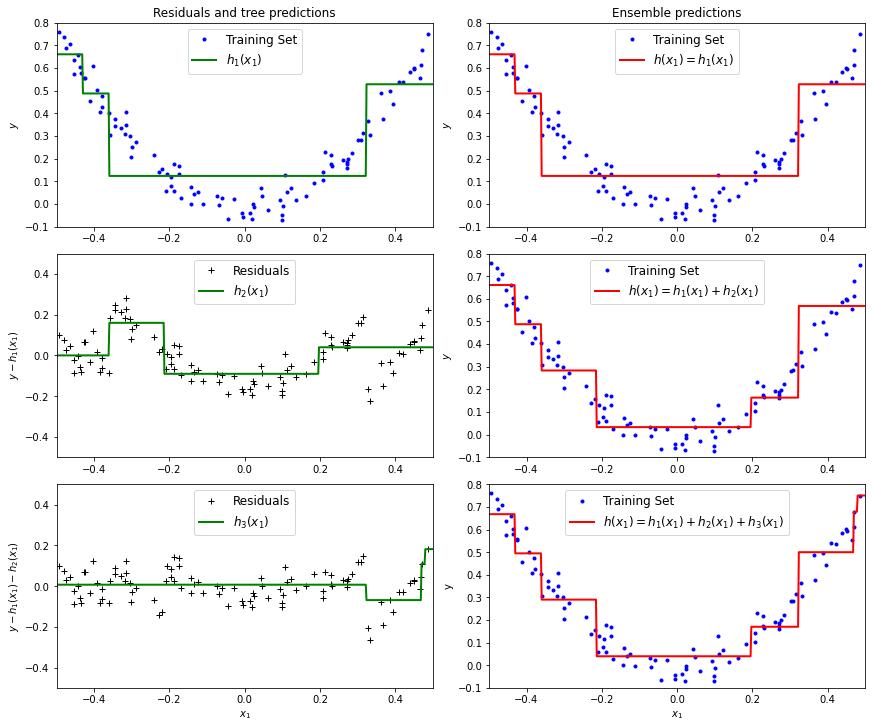

In [41]:
_, axes = plt.subplots(3,
                       2,
                       figsize=(12, 10),
                       
                       constrained_layout=True)

data_ys = [y, y, y2, y, y3, y]
regs = [[tree_reg1], [tree_reg1], [tree_reg2], [tree_reg1, tree_reg2],
         [tree_reg3], [tree_reg1, tree_reg2, tree_reg3]]
lims = [[-0.5, 0.5, -0.1, 0.8], [-0.5, 0.5, -0.1, 0.8], [-0.5, 0.5, -0.5, 0.5],
        [-0.5, 0.5, -0.1, 0.8], [-0.5, 0.5, -0.5, 0.5], [-0.5, 0.5, -0.1, 0.8]]
labels = [
    "$h_1(x_1)$", "$h(x_1) = h_1(x_1)$", "$h_2(x_1)$",
    "$h(x_1) = h_1(x_1) + h_2(x_1)$", "$h_3(x_1)$",
    "$h(x_1) = h_1(x_1) + h_2(x_1) + h_3(x_1)$"
]
ylabels = [
    "$y$", "$y$", "$y - h_1(x_1)$", "$y$", "$y - h_1(x_1) - h_2(x_1)$", "y"
]
ensembles = [False, True, False, True, False, True]
residuals = [False, False, True, False, True, False]

for reg, data_y, lim, ylabel, label, ensemble, residual, ax in zip(
        regs, data_ys, lims, ylabels, labels, ensembles, residuals,
        axes.flatten()):

    plot_predictions(reg,
                     X,
                     data_y,
                     ax,
                     lims=lim,
                     ensemble=ensemble,
                     residual=residual,
                     label=label)
    ax.set(ylabel=ylabel)

axes[0, 0].set(title="Residuals and tree predictions")
axes[0, 1].set(title="Ensemble predictions")
axes[2, 0].set(xlabel="$x_1$")
axes[2, 1].set(xlabel="$x_1$")

plt.show()

In [42]:
from sklearn.ensemble import GradientBoostingRegressor

In [43]:
gbrt = GradientBoostingRegressor(max_depth=2,
                                 n_estimators=3,
                                 learning_rate=1.0,
                                 random_state=42)
gbrt.fit(X, y)

GradientBoostingRegressor(learning_rate=1.0, max_depth=2, n_estimators=3,
                          random_state=42)

In [44]:
gbrt_slow = GradientBoostingRegressor(max_depth=2,
                                      n_estimators=200,
                                      learning_rate=0.1,
                                      random_state=42)
gbrt_slow.fit(X, y)

GradientBoostingRegressor(max_depth=2, n_estimators=200, random_state=42)

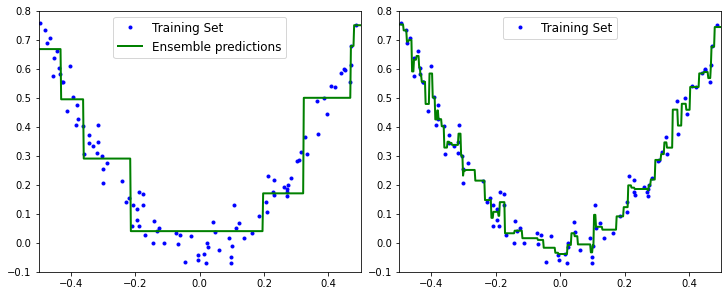

In [45]:
_, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

plot_predictions([gbrt],
                 X,
                 y,
                 ax=axes[0],
                 lims=[-0.5, 0.5, -0.1, 0.8],
                 label="Ensemble predictions")
ax.set(xlabel="$x_1$",
       ylabel="$y$",
       title=
       f"learning_rate={gbrt.learning_rate}, n_estimators={gbrt.n_estimators}")

plot_predictions([gbrt_slow], X, y, lims=[-0.5, 0.5, -0.1, 0.8], ax=axes[1])
ax.set(
    xlabel="$x_1$",
    title=
    f"learning_rate={gbrt_slow.learning_rate}, n_estimators={gbrt_slow.n_estimators}",
)

plt.show()

### 早停

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [47]:
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=49)

gbrt = GradientBoostingRegressor(max_depth=2,
                                 n_estimators=120,
                                 random_state=42)
gbrt.fit(X_train, y_train)

errors = [
    mean_squared_error(y_val, y_pred) for y_pred in gbrt.staged_predict(X_val)
]
bst_n_estimators = np.argmin(errors) + 1

gbrt_best = GradientBoostingRegressor(max_depth=2,
                                      n_estimators=bst_n_estimators,
                                      random_state=42)
gbrt_best.fit(X_train, y_train)

GradientBoostingRegressor(max_depth=2, n_estimators=56, random_state=42)

In [48]:
min_error = np.min(errors)

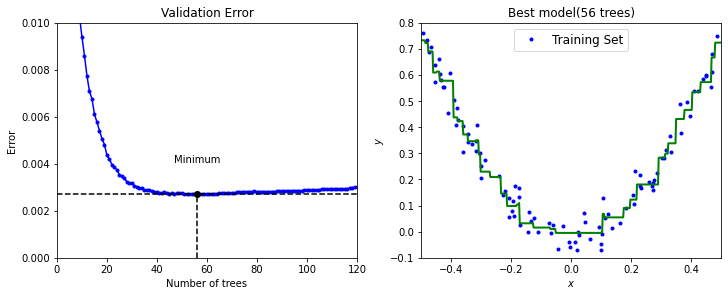

In [49]:
_, axes = plt.subplots(1, 2, figsize=(10, 4),  constrained_layout=True)

axes[0].plot(errors, "b.-")
axes[0].plot([bst_n_estimators, bst_n_estimators], [0, min_error], "k--")
axes[0].plot([0, 120], [min_error, min_error], "k--")

axes[0].plot(bst_n_estimators, min_error, "ko")
axes[0].text(bst_n_estimators,
             min_error * 1.5,
             "Minimum",
             ha="center",
             fontsize='medium')
axes[0].set(xlim=[0, 120],
            ylim=[0, 0.01],
            xlabel="Number of trees",
            ylabel="Error",
            title="Validation Error")

plot_predictions([gbrt_best], X, y, lims=[-0.5, 0.5, -0.1, 0.8], ax=axes[1])
axes[1].set(xlabel="$x$",
            ylabel="$y$",
            title=f"Best model({bst_n_estimators} trees)")

plt.show()

In [50]:
gbrt = GradientBoostingRegressor(max_depth=2, warm_start=True, random_state=42)

min_val_error = float("inf")
error_going_up = 0
for n_estimators in range(1, 120):
    gbrt.n_estimators = n_estimators
    gbrt.fit(X_train, y_train)
    y_pred = gbrt.predict(X_val)
    val_error = mean_squared_error(y_val, y_pred)
    if val_error < min_val_error:
        min_val_error = val_error
        error_going_up = 0
    else:
        error_going_up += 1
        if error_going_up == 5:
            break  # early stopping

In [51]:
print(gbrt.n_estimators)

61


In [52]:
print("Minimum validation MSE:", min_val_error)

Minimum validation MSE: 0.002712853325235463


# LightGBM

In [53]:
mnist_784 = np.load('../../datasets/handson/mnist_784.npz', allow_pickle=True)
X, y = mnist_784['X'], mnist_784['y']

In [54]:
from sklearn.model_selection import train_test_split

In [55]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X,
                                                            y,
                                                            test_size=10000,
                                                            random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val,
                                                  y_train_val,
                                                  test_size=10000,
                                                  random_state=42)

In [56]:
X_train = X_train.reshape(-1, 784).astype('float32')
X_val = X_val.reshape(-1, 784).astype('float32')
X_test = X_test.reshape(-1, 784).astype('float32')

X_train /= 255
X_val /= 255
X_test /= 255

In [57]:
import lightgbm as lgb
from sklearn.model_selection import KFold, StratifiedKFold

In [58]:
# if you want to re-use data, remember to set free_raw_data=False
lgb_train = lgb.Dataset(X_train, y_train, free_raw_data=False)

lgb_eval = lgb.Dataset(X_val, y_val, reference=lgb_train, free_raw_data=False)

In [59]:
params = {
    'n_estimators': 2000,
    'max_depth': 8,
    'subsample': 0.8,
    'learning_rate': 0.1,
    'num_leaves': 2**8-1,
}

In [60]:
def objective(trial):
    kf = KFold(n_splits=3)
    gbm = lgb.LGBMClassifier(objective='binary')
    oof = np.zeros(len(X_train))

    for fold, (train_index,
               valid_index) in enumerate(kf.split(X_train, y_train)):
        train_x, valid_x = X_train[train_index], X_train[valid_index]
        train_y, valid_y = y_train[train_index], y_train[valid_index]
        gbm = lgb.LGBMClassifier(
            objective='binary',
            **params,
            colsample_bytree=trial.suggest_loguniform('colsample_bytree', 1e-4,
                                                      1.0),
            colsample_bynode=trial.suggest_loguniform('colsample_bynode', 1e-4,
                                                      1.0),
            reg_alpha=trial.suggest_loguniform('reg_alpha', 1e-4, 100.0),
            reg_lambda=trial.suggest_loguniform('reg_lambda', 1e-4, 100.0),
            verbose=1)
        gbm.fit(train_x,
                train_y,
                eval_set=[(valid_x, valid_y)],
                callbacks=[
                    lgb.early_stopping(3, first_metric_only=True),
                    lgb.log_evaluation()
                ])
        oof[valid_index] = gbm.predict(valid_x,
                                       num_iteration=gbm.best_iteration_)

    accuracy = accuracy_score(y_train, oof)
    return 1.0 - accuracy

In [61]:
from optuna import create_study
from optuna import samplers

In [62]:
# study = create_study(sampler=samplers.RandomSampler(seed=0))
# study.optimize(objective, n_trials=1)

In [63]:
params2 = {
    'n_estimators': 2000,
    'max_depth': 8,
    'subsample': 0.8,
    'learning_rate': 0.1,
    'num_leaves': 2**8-1,
    # manual copy of the result of tuning
    'colsample_bytree': 0.7155682161754863,
    'colsample_bynode': 0.0034179529120610124,
    'reg_alpha': 5.627949975223147,
    'reg_lambda': 0.1490628836610165
}

In [64]:
# kf = KFold(n_splits=3)
# oof = np.zeros(len(X_train))

# for fold, (train_index, valid_index) in enumerate(kf.split(X_train, y_train)):
#     train_x, valid_x = X_train[train_index], X_train[valid_index]
#     train_y, valid_y = y_train[train_index], y_train[valid_index]
#     gbm2 = lgb.LGBMClassifier(objective='binary', **params2)
#     gbm2.fit(train_x,
#             train_y,
#             eval_set=[(valid_x, valid_y)],
#             callbacks=[lgb.early_stopping(3),
#                        lgb.log_evaluation()])
#     oof[valid_index] = gbm2.predict(valid_x,
#                                     num_iteration=gbm2.best_iteration_)

# round(accuracy_score(y_train, oof), 3)

In [65]:
# from sklearn.metrics import accuracy_score

# y_pred = gbm2.predict(X_test)
# print(y_pred.shape)
# print(y_pred[0])
# print(f'accuracy_score:{accuracy_score(y_test, y_pred)}')